# Obligatorio - Taller de Inteligencia Artificial 2025

## Ramiro Sanes (368397) - Joaquin Guerra (307854)

## Agentes implementados utilizando Replay Memory con Prioridad


### Los agentes

Se entrenaron el "DQN Agent" y el "Double DQN Agent" utilizando Replay Memory con prioridad.
Se modificó la configuración de algunos hiperparámetros: BUFFER_SIZE = 10.000 y EPISODES = 5.000.
Los detalles sobre la implementación de la Replay Memory con prioridad se encuentran en el notebook principal.

In [3]:
import os
import torch
import numpy as np
import random
import numpy as np
import gymnasium
import ale_py
from IPython.display import Video

from utils import make_env, process_state, show_observation_stack, plot_rewards_and_max_values
from dqn_agent import DQNAgent
from dqn_cnn_model import DQN_CNN_Model
from double_dqn_agent import DoubleDQNAgent

In [4]:
SEED = 23

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic=True # https://discuss.pytorch.org/t/what-is-the-differenc-between-cudnn-deterministic-and-cudnn-benchmark/38054
torch.backends.cudnn.benchmark=True # https://discuss.pytorch.org/t/what-does-torch-backends-cudnn-benchmark-do/5936/4
np.random.seed(SEED)
random.seed(SEED)

In [5]:
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"  
elif torch.backends.mps.is_available():
    DEVICE = "mps" 

In [6]:
GRAY_SCALE = True 
SCREEN_SIZE = 84 
NUM_STACKED_FRAMES = 4 
SKIP_FRAMES = 4 
ENV_NAME = "ALE/Breakout-v5" 

## Entrenamiento

### Entrenamos al agente DQNAgent y medimos sus resultados

Achicamos el buffer size ya que se nos hace muy costoso el samplear de un buffer mas grande y demora el entrenamiento. Y creemos que al estar priorizadas, las transiciones con menor TD difference quedaran despriorizadas entre las 50K y no serían tan necesarias. 

Bajamos la cantidad de episodios de entrenamiento a 5000

In [7]:
#Hiperparámetros de entrenamiento del agente DQN
TOTAL_STEPS = 10_000_000
EPISODES = 5_000
#EPISODES = 10_000
#EPISODES = 100
STEPS_PER_EPISODE = 20_000

EPSILON_INI = 1
EPSILON_MIN = 0.05
EPSILON_ANNEAL_STEPS = 1_000_000

EPISODE_BLOCK = 100

BATCH_SIZE = 32
BUFFER_SIZE = 10_000

GAMMA = 0.995
LEARNING_RATE = 1e-5

Creamos el agente con el parámetro with_priority = True para que implemente la memoria con prioridad

In [8]:
env = make_env(ENV_NAME,
                video_folder='./videos/dqn_training_prio',
                name_prefix="breakout",
                record_every=500,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)

dqn_agent_prio = DQNAgent(env, net, process_state, BUFFER_SIZE, BATCH_SIZE, LEARNING_RATE, GAMMA, 
                     epsilon_i=EPSILON_INI, epsilon_f=EPSILON_MIN, 
                     epsilon_anneal_steps=EPSILON_ANNEAL_STEPS, 
                     episode_block=EPISODE_BLOCK, device=DEVICE, with_priority= True)



A.L.E: Arcade Learning Environment (version 0.11.1+2750686)
[Powered by Stella]


Generamos una lista con 10 estados procesados al azar, para evaluar el valor de las funciones en esos estados durante el entrenamiento.

In [9]:
state_eval_list = []
for _ in range(10):
    state_eval_list.append(process_state(env.reset()[0],DEVICE))


Los videos del entrenamiento serán guardados en './videos/dqn_training' y se guardarán los pesos de la red cada 1000 pasos.

In [10]:
rewards_1, state_values_1 = dqn_agent_prio.train(EPISODES, STEPS_PER_EPISODE, TOTAL_STEPS, random_states = state_eval_list)

Training:  20%|██        | 1000/5000 [23:38<2:06:54,  1.90s/episode, reward=1.77, epsilon=0.831, steps=177609]

Checkpoint saved to weights/dqn_prio/checkpoint_1000_version_2


Training:  40%|████      | 2000/5000 [51:30<1:24:47,  1.70s/episode, reward=2.88, epsilon=0.637, steps=382611]

Checkpoint saved to weights/dqn_prio/checkpoint_2000_version_2


Training:  60%|██████    | 3000/5000 [1:27:45<1:24:30,  2.54s/episode, reward=4.18, epsilon=0.383, steps=649925]

Checkpoint saved to weights/dqn_prio/checkpoint_3000_version_2


Training:  80%|████████  | 4000/5000 [2:17:51<46:20,  2.78s/episode, reward=7.33, epsilon=0.05, steps=1015823]   

Checkpoint saved to weights/dqn_prio/checkpoint_4000_version_2


Training: 100%|██████████| 5000/5000 [3:16:46<00:00,  2.36s/episode, reward=8.61, epsilon=0.05, steps=1446820]  

Checkpoint saved to weights/dqn_prio/checkpoint_5000_version_2


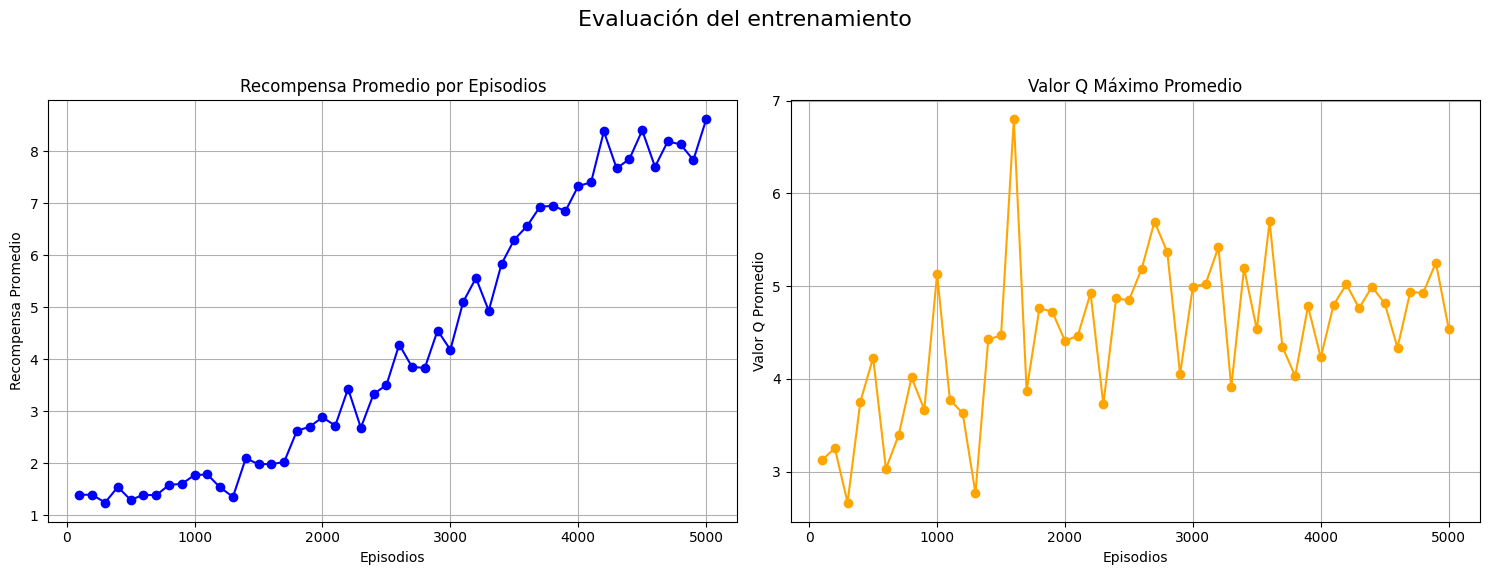

In [11]:
plot_rewards_and_max_values(rewards_1, state_values_1, "DQN Agent con Memoria Priorizada", "Evaluación del entrenamiento")

## Resultados

Hacemos que el agente juegue 10 episodios y mostramos el desempeño

In [27]:
env = make_env(ENV_NAME,
                video_folder='./videos/dqn_test_prio',
                name_prefix="breakout",
                record_every=1,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

In [28]:
checkpoint_path = "checkpoint_5000_version_2"
print(f"Cargando checkpoint desde {checkpoint_path}")
dqn_agent_prio.load_checkpoint(checkpoint_path,True)

retornos = dqn_agent_prio.play(env=env, episodes=10)

print(retornos.argmax())


video_path = f"./videos/dqn_test_prio/breakout-episode-{retornos.argmax()}.mp4"

print(f"El agente DQNAgent con Memoria Priorizada obtuvo un retorno promedio de {retornos.mean()} en {len(retornos)} episodios. \n Y el mejor retorno fue {retornos.max()} en el episodio {retornos.argmax()}.")

# Muestra el vídeo
Video(video_path, embed=True, width=600)

Cargando checkpoint desde checkpoint_5000_version_2
Checkpoint loaded from weights/dqn_prio/checkpoint_5000_version_2
1
El agente DQNAgent con Memoria Priorizada obtuvo un retorno promedio de 8.6 en 10 episodios. 
 Y el mejor retorno fue 14.0 en el episodio 1.


### Entrenamos al agente DoubleDQNAgent y medimos sus resultados

Utilizamos los mismos hiperparámetros que el agente DQNAgent.

In [20]:
env = make_env(ENV_NAME,
                video_folder='./videos/ddqn_training_prio',
                name_prefix="breakout",
                record_every=500,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)
target_net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)

double_dqn_agent_prio = DoubleDQNAgent(env, net,target_net, process_state, BUFFER_SIZE, BATCH_SIZE, LEARNING_RATE, GAMMA, 
                     epsilon_i=EPSILON_INI, epsilon_f=EPSILON_MIN, 
                     epsilon_anneal_steps=EPSILON_ANNEAL_STEPS, 
                     episode_block=EPISODE_BLOCK, device=DEVICE, with_priority= True)



In [16]:
rewards_2, state_values_2 = double_dqn_agent_prio.train(EPISODES, STEPS_PER_EPISODE, TOTAL_STEPS,random_states = state_eval_list)

Training:  20%|██        | 1000/5000 [22:40<1:30:23,  1.36s/episode, reward=1.12, epsilon=0.839, steps=169910]

Checkpoints saved to weights/ddqn_prio/checkpoint_1000_policy_net.pth and weights/ddqn_prio/checkpoint_1000_target_net.pth


Training:  40%|████      | 2000/5000 [48:52<1:35:55,  1.92s/episode, reward=2.5, epsilon=0.655, steps=363409] 

Checkpoints saved to weights/ddqn_prio/checkpoint_2000_policy_net.pth and weights/ddqn_prio/checkpoint_2000_target_net.pth


Training:  60%|██████    | 3000/5000 [1:26:50<1:24:43,  2.54s/episode, reward=4.44, epsilon=0.393, steps=638477]

Checkpoints saved to weights/ddqn_prio/checkpoint_3000_policy_net.pth and weights/ddqn_prio/checkpoint_3000_target_net.pth


Training:  80%|████████  | 4000/5000 [2:19:40<1:10:21,  4.22s/episode, reward=8.21, epsilon=0.05, steps=1012587] 

Checkpoints saved to weights/ddqn_prio/checkpoint_4000_policy_net.pth and weights/ddqn_prio/checkpoint_4000_target_net.pth


Training: 100%|██████████| 5000/5000 [3:22:58<00:00,  2.44s/episode, reward=8.86, epsilon=0.05, steps=1462698]  

Checkpoints saved to weights/ddqn_prio/checkpoint_5000_policy_net.pth and weights/ddqn_prio/checkpoint_5000_target_net.pth


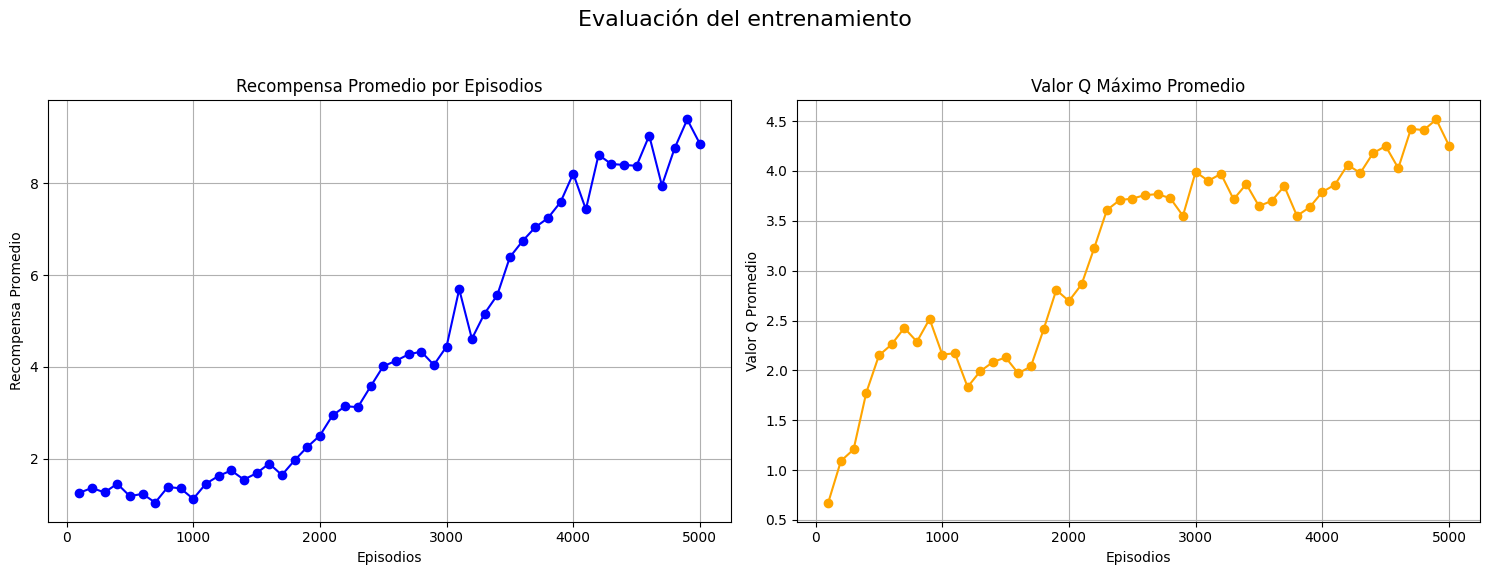

In [17]:
plot_rewards_and_max_values(rewards_2, state_values_2, "Double DQN Agent con Memoria Priorizada", "Evaluación del entrenamiento",)

Hacemos que el agente juegue 10 episodios y mostramos el desempeño

In [26]:

env = make_env(ENV_NAME,
                video_folder='./videos/ddqn_test_prio',
                name_prefix="breakout",
                record_every=1,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

checkpoint_path = "checkpoint_5000"
print(f"Cargando checkpoint desde {checkpoint_path}")
double_dqn_agent_prio.load_checkpoint(checkpoint_path,True)

retornos = double_dqn_agent_prio.play(env=env, episodes=10)


video_path = f"./videos/ddqn_test_prio/breakout-episode-{retornos.argmax()}.mp4"

print(f"El agente DoubleDQNAgent con Memoria Priorizada obtuvo un retorno promedio de {retornos.mean()} en {len(retornos)} episodios. \n Y el mejor retorno fue {retornos.max()} en el episodio {retornos.argmax()}.")

# Muestra el vídeo
Video(video_path, embed=True, width=600)

Cargando checkpoint desde checkpoint_5000
Checkpoints loaded from weights/ddqn_prio/checkpoint_5000_policy_net.pth and weights/ddqn_prio/checkpoint_5000_target_net.pth
El agente DoubleDQNAgent con Memoria Priorizada obtuvo un retorno promedio de 11.1 en 10 episodios. 
 Y el mejor retorno fue 16.0 en el episodio 6.
